In [1]:
words = open("data/names.txt", 'r').read().splitlines()

In [3]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

print(len(b))

627


In [ ]:
chats = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chats)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


In [22]:
import torch
N = torch.zeros((27,27), dtype=torch.int32)
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

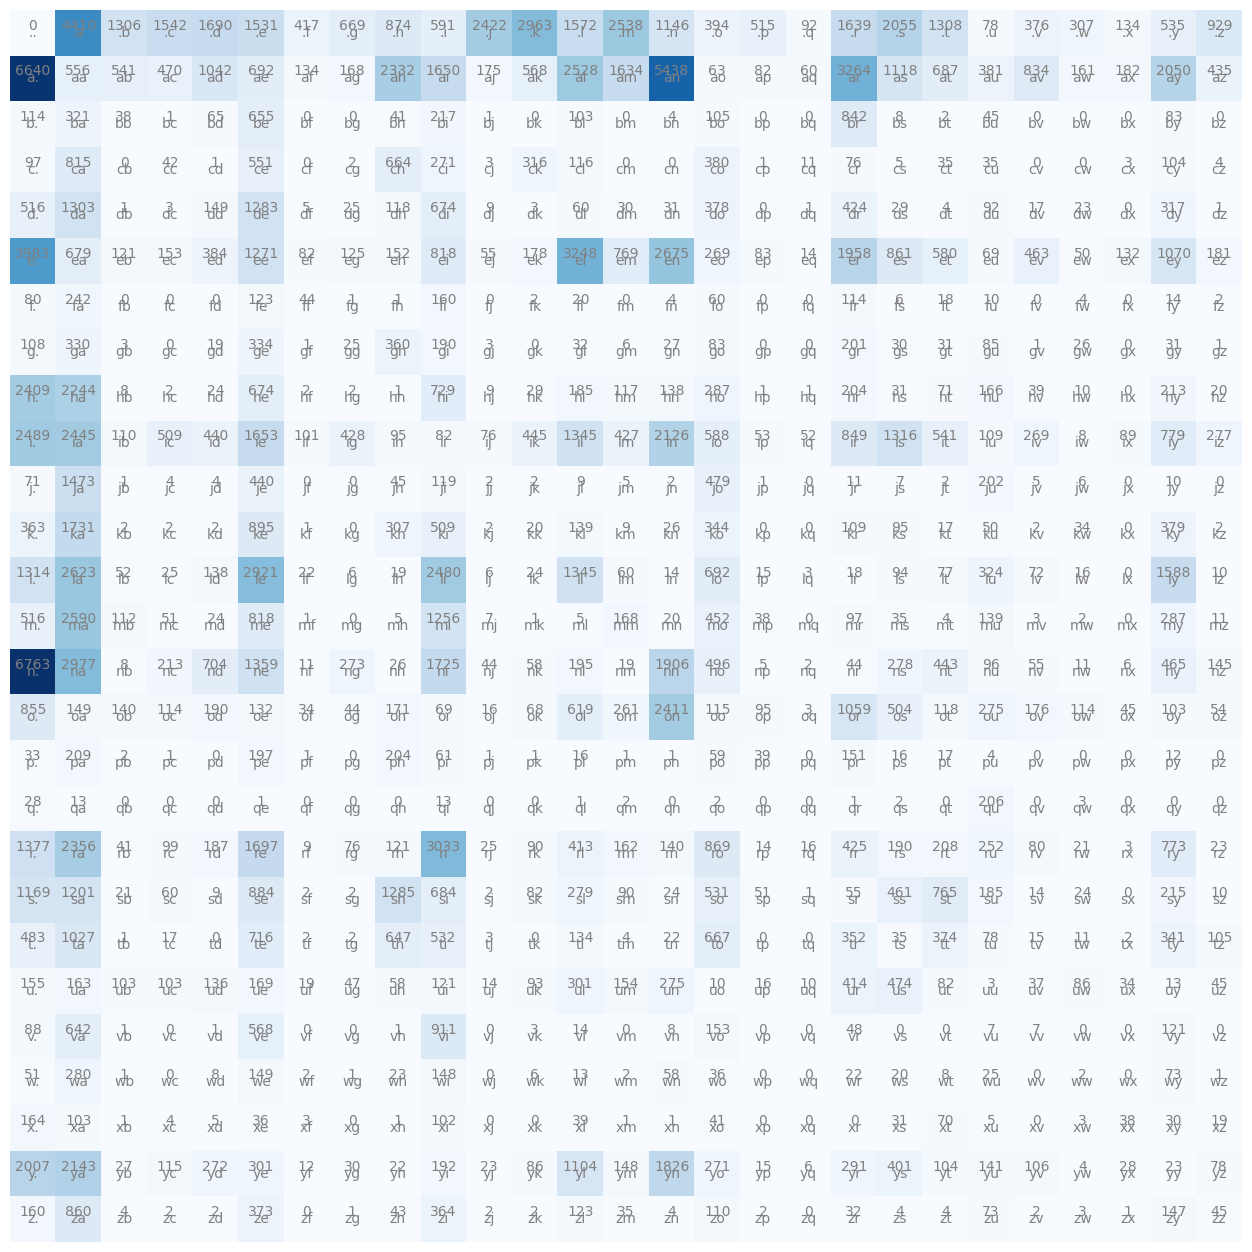

In [23]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='center', color='gray')
        plt.text(j, i, N[i,j].item(), ha='center', va='bottom', color='gray')
plt.axis('off')

## Random Sampling

In [28]:
P = (N+1).float()   
P = P / P.sum(1, keepdim=True)

In [29]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20):
    ix = 0
    out = []
    while True: 
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


# Neural Network

In [75]:
xs ,ys = [], []
for w in words: 
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[0:-1]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)  
x = torch.tensor(xs)
y = torch.tensor(ys)

In [76]:
from torch.nn import functional as F
xenc = F.one_hot(x, num_classes=27).float()
yenc = F.one_hot(y, num_classes=27).float()
W = torch.randn((27,27), requires_grad=True)
b = torch.randn(27, requires_grad=True)


## Training Loop

In [77]:
epochs = 1000
for epoch in range(epochs):
    logits = xenc @ W + b   # (N, 27)
    loss = F.cross_entropy(logits, y)

    W.grad = None
    b.grad = None
    loss.backward()

    W.data += -50 * W.grad
    b.data += -50 * b.grad

    if epoch % 100 == 0:
        print(epoch, loss.item())

0 3.8787097930908203
100 0.005161796696484089
200 0.0024975992273539305
300 0.0016514640301465988
400 0.001234993920661509
500 0.000986885977908969
600 0.0008221049210987985
700 0.0007046232931315899
800 0.0006166173843666911
900 0.0005482097039930522


In [78]:
for i in range(20):
    ix = 0
    out = []
    while True: 
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W + b   # (1, 27)
        probs = F.softmax(logits, dim=1).squeeze()  # (27
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.


# Trigram NN

In [51]:
t = {}
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2,ch3 in zip(chs, chs[1:], chs[2:]):
        trigram = (ch1, ch2, ch3)
        t[trigram] = t.get(trigram, 0) + 1

In [64]:
chars = ['.'] + list("abcdefghijklmnopqrstuvwxyz")
itos_t = []
for c1 in chars:
    for c2 in chars:
        itos_t.append(c1 + c2)

itos_t = sorted(itos_t)
stoi_t = {s:i for i,s in enumerate(itos_t)}

In [67]:
new_N = torch.zeros((729,27), dtype=torch.int32)
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[0:-2], chs[2:]):
        ix1 = stoi_t[ch1 + ch2]
        ix2 = stoi[ch3]
        new_N[ix1, ix2] += 1